In [94]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from astropy import units as u

import scopesim as sim
import scopesim_templates as sim_tp

In [107]:
## Set up ZShooter
cmd = sim.UserCommands(use_instrument="ZShooter", set_modes=["SPEC"])
zs = sim.OpticalTrain(cmd)

In [108]:
# zs["image_slicer"].include = False
# zs["telescope_reflection"].include = False
# zs["seeing_psf"].include = False
# zs["maunakea_atmospheric_transmission"].include = False
zs.effects

element,name,class,included
str17,str33,str22,bool
MaunaKea,maunakea_atmospheric_transmission,TERCurve,True
MaunaKea,seeing_psf,SeeingPSF,True
keck,telescope_reflection,SurfaceList,True
zshooter_detector,4k_detector,DetectorList,True
zshooter_detector,exposure_integration,ExposureIntegration,True
zshooter_detector,dark_current,DarkCurrent,True
zshooter_detector,shot_noise,ShotNoise,True
zshooter_detector,detector_linearity,LinearityCurve,False
zshooter_detector,border_reference_pixels,ReferencePixelBorder,True


In [114]:
wave = np.linspace(0.7, 2.2, 1001) * u.um
gal = sim_tp.extragalactic.galaxies.spiral_two_component(extent=200*u.arcsec, fluxes=(15, 15)*u.mag)
gal.shift(dy=-30*0.004)
# plt.figure(figsize=(15,8))
# for i, c in zip([0, 1], "rb"):
#     plt.subplot(2,2,2*i+1)
#     plt.imshow(gal.fields[i].data, origin="lower")
#     plt.subplot(2,2,2*i+2)
#     plt.plot(wave, gal.spectra[i](wave), c=c)

In [115]:
zs.observe(gal, update=True)


 FOVs: 100%|██████████| 3/3 [00:02<00:00,  1.16it/s]


In [111]:
zs.fov_manager.fovs

[FieldOfView2D(NAXIS   =                    2                                                  
 NAXIS1  =                 3937                                                  
 NAXIS2  =                 3937                                                  
 WCSAXES =                    2 / Number of coordinate axes                      
 CRPIX1  =               1969.0 / Pixel coordinate of reference point            
 CRPIX2  =               1969.0 / Pixel coordinate of reference point            
 CDELT1  =  3.5277777777778E-05 / [deg] Coordinate increment at reference point  
 CDELT2  =  3.5277777777778E-05 / [deg] Coordinate increment at reference point  
 CUNIT1  = 'deg'                / Units of coordinate increment and value        
 CUNIT2  = 'deg'                / Units of coordinate increment and value        
 CTYPE1  = 'LINEAR'             / Coordinate type code                           
 CTYPE2  = 'LINEAR'             / Coordinate type code                           
 C

astar.scopesim.detector.detector_manager - Extracting from 1 detectors...
astar.scopesim.optics.optical_train - ERROR: Header update failed, data will be saved with incomplete header. See stack trace for details.
Traceback (most recent call last):
  File "/Users/yashvi/Desktop/ZShooter/.venv/lib/python3.12/site-packages/scopesim/optics/optical_train.py", line 474, in readout
    hdul = self.write_header(hdul)
           ^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/yashvi/Desktop/ZShooter/.venv/lib/python3.12/site-packages/scopesim/optics/optical_train.py", line 537, in write_header
    iheader["DETECTOR"] = eff.meta["detector"]
                          ~~~~~~~~^^^^^^^^^^^^
KeyError: 'detector'


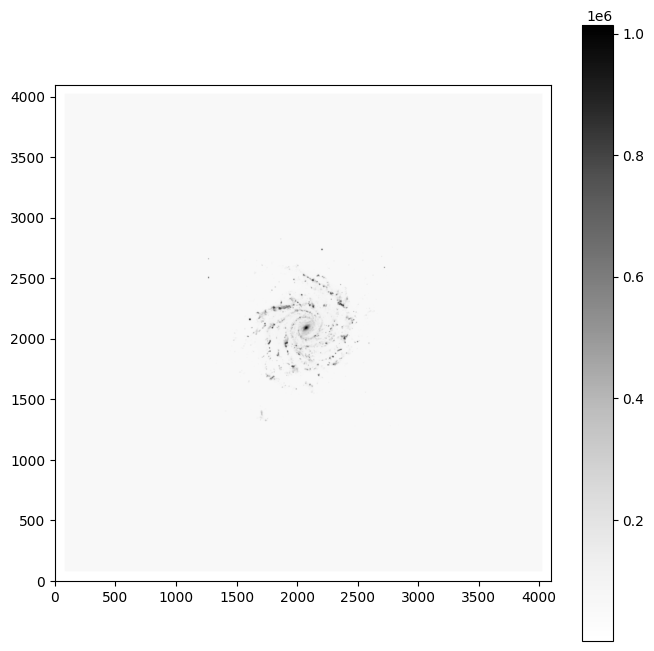

In [117]:
hdus = zs.readout()
plt.figure(figsize=(8,8))
plt.imshow(hdus[0][1].data, origin="lower", cmap="Grays")
plt.colorbar()